In [2]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Carichiamo il dataset
df = pd.read_excel('../data/Volve production data.xlsx')

# Lavoriamo sui 3 pozzi target
pozzi_target = ['NO 15/9-F-12 H', 'NO 15/9-F-14 H', 'NO 15/9-F-11 H']

# Prendiamo F-14 H per iniziare
pozzo = 'NO 15/9-F-14 H'
df_pozzo = df[df['WELL_BORE_CODE'] == pozzo].copy()
df_pozzo = df_pozzo.sort_values('DATEPRD').reset_index(drop=True)

# Teniamo solo i giorni in produzione
df_prod = df_pozzo[df_pozzo['BORE_OIL_VOL'] > 0].copy().reset_index(drop=True)

# Feature per anomaly detection
df_prod['GOR'] = df_prod['BORE_GAS_VOL'] / df_prod['BORE_OIL_VOL'].replace(0, np.nan)
df_prod['WATERCUT'] = df_prod['BORE_WAT_VOL'] / (df_prod['BORE_OIL_VOL'] + df_prod['BORE_WAT_VOL']).replace(0, np.nan)
df_prod['OIL_ROLL7'] = df_prod['BORE_OIL_VOL'].rolling(7).mean()
df_prod['OIL_DIFF'] = df_prod['BORE_OIL_VOL'].diff()  # variazione giornaliera

df_ad = df_prod[['DATEPRD', 'BORE_OIL_VOL', 'GOR', 'WATERCUT', 
                  'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS',
                  'OIL_ROLL7', 'OIL_DIFF']].dropna().reset_index(drop=True)

print(f"Righe disponibili per anomaly detection: {len(df_ad)}")
print(f"Feature utilizzate: {list(df_ad.columns[1:])}")

Righe disponibili per anomaly detection: 2711
Feature utilizzate: ['BORE_OIL_VOL', 'GOR', 'WATERCUT', 'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS', 'OIL_ROLL7', 'OIL_DIFF']


In [3]:
# ── ISOLATION FOREST ─────────────────────────────────────────────────────────

# Feature su cui cercare anomalie (escludiamo la data)
features_ad = ['BORE_OIL_VOL', 'GOR', 'WATERCUT', 
               'AVG_DOWNHOLE_PRESSURE', 'ON_STREAM_HRS',
               'OIL_ROLL7', 'OIL_DIFF']

X_ad = df_ad[features_ad].values

# Normalizziamo
scaler_ad = MinMaxScaler()
X_scaled = scaler_ad.fit_transform(X_ad)

# Isolation Forest
# contamination = percentuale attesa di anomalie nel dataset (5%)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Fit e predizione: -1 = anomalia, 1 = normale
df_ad['ANOMALY_IF'] = iso_forest.fit_predict(X_scaled)
df_ad['ANOMALY_SCORE'] = iso_forest.score_samples(X_scaled)

n_anomalie = (df_ad['ANOMALY_IF'] == -1).sum()
print(f"Anomalie rilevate: {n_anomalie} su {len(df_ad)} giorni ({n_anomalie/len(df_ad)*100:.1f}%)")

Anomalie rilevate: 136 su 2711 giorni (5.0%)


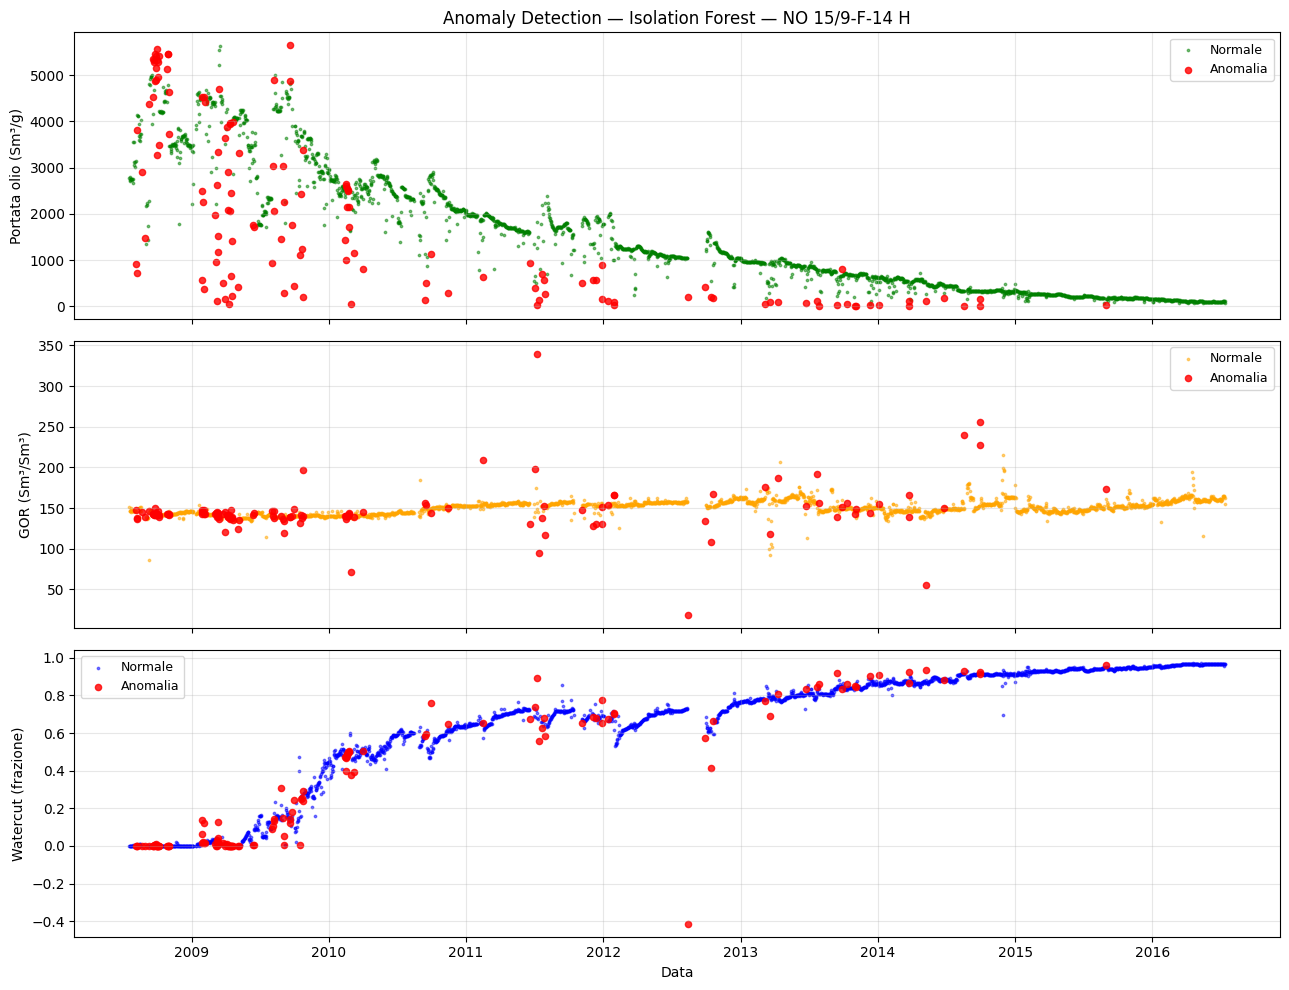

In [4]:
# ── VISUALIZZAZIONE ANOMALIE ──────────────────────────────────────────────────

normali  = df_ad[df_ad['ANOMALY_IF'] ==  1]
anomalie = df_ad[df_ad['ANOMALY_IF'] == -1]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# ── Grafico 1: Produzione olio ──
axes[0].scatter(normali['DATEPRD'],  normali['BORE_OIL_VOL'],  
                color='green', s=3, alpha=0.5, label='Normale')
axes[0].scatter(anomalie['DATEPRD'], anomalie['BORE_OIL_VOL'], 
                color='red', s=20, alpha=0.8, label='Anomalia')
axes[0].set_ylabel('Portata olio (Sm³/g)')
axes[0].set_title(f'Anomaly Detection — Isolation Forest — {pozzo}')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Grafico 2: GOR ──
axes[1].scatter(normali['DATEPRD'],  normali['GOR'],  
                color='orange', s=3, alpha=0.5, label='Normale')
axes[1].scatter(anomalie['DATEPRD'], anomalie['GOR'], 
                color='red', s=20, alpha=0.8, label='Anomalia')
axes[1].set_ylabel('GOR (Sm³/Sm³)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Grafico 3: Watercut ──
axes[2].scatter(normali['DATEPRD'],  normali['WATERCUT'],  
                color='blue', s=3, alpha=0.5, label='Normale')
axes[2].scatter(anomalie['DATEPRD'], anomalie['WATERCUT'], 
                color='red', s=20, alpha=0.8, label='Anomalia')
axes[2].set_ylabel('Watercut (frazione)')
axes[2].set_xlabel('Data')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ── SISTEMA DI ALERT ─────────────────────────────────────────────────────────

def classifica_anomalia(row):
    """Classifica il tipo e la severità dell'anomalia"""
    
    # Valori di riferimento normali
    GOR_NORMALE    = 155  # Sm³/Sm³ media del pozzo
    GOR_SOGLIA     = 200  # sopra questa soglia = alert GOR
    WC_SOGLIA_NEG  = 0    # watercut non può essere negativo
    OIL_DIFF_SOGLIA = -500 # calo giornaliero anomalo
    
    tipo   = "GENERICO"
    severita = "BASSA"
    causa  = "Comportamento statisticamente anomalo"
    
    # Watercut negativo = errore di misura
    if row['WATERCUT'] < WC_SOGLIA_NEG:
        tipo     = "ERRORE MISURA"
        severita = "ALTA"
        causa    = "Watercut negativo — probabile errore sensore"
    
    # GOR molto alto = possibile gas coning
    elif row['GOR'] > GOR_SOGLIA:
        tipo     = "GOR ANOMALO"
        severita = "ALTA" if row['GOR'] > 250 else "MEDIA"
        causa    = "GOR elevato — possibile gas coning o problema al separatore"
    
    # GOR molto basso
    elif row['GOR'] < 80:
        tipo     = "GOR BASSO"
        severita = "MEDIA"
        causa    = "GOR insolitamente basso — verificare strumentazione"
    
    # Calo produzione improvviso
    elif row['OIL_DIFF'] < OIL_DIFF_SOGLIA:
        tipo     = "CALO PRODUZIONE"
        severita = "ALTA"
        causa    = "Calo produzione improvviso — possibile shut-in o problema meccanico"
    
    return pd.Series([tipo, severita, causa])

# Applichiamo la classificazione solo alle anomalie
anomalie_df = df_ad[df_ad['ANOMALY_IF'] == -1].copy()
anomalie_df[['TIPO', 'SEVERITA', 'CAUSA']] = anomalie_df.apply(classifica_anomalia, axis=1)

# Tabella riassuntiva
print("══ SISTEMA DI ALERT — ANOMALIE RILEVATE ══\n")
print(f"Totale anomalie: {len(anomalie_df)}\n")
print("Distribuzione per tipo:")
print(anomalie_df['TIPO'].value_counts().to_string())
print("\nDistribuzione per severità:")
print(anomalie_df['SEVERITA'].value_counts().to_string())

print("\n── Anomalie ad alta severità ──")
alta = anomalie_df[anomalie_df['SEVERITA'] == 'ALTA'][['DATEPRD', 'TIPO', 'CAUSA', 'BORE_OIL_VOL', 'GOR', 'WATERCUT']]
print(alta.to_string(index=False))

══ SISTEMA DI ALERT — ANOMALIE RILEVATE ══

Totale anomalie: 136

Distribuzione per tipo:
TIPO
GENERICO           67
CALO PRODUZIONE    61
GOR ANOMALO         5
GOR BASSO           2
ERRORE MISURA       1

Distribuzione per severità:
SEVERITA
BASSA    67
ALTA     64
MEDIA     5

── Anomalie ad alta severità ──
   DATEPRD            TIPO                                                               CAUSA  BORE_OIL_VOL        GOR  WATERCUT
2008-08-06 CALO PRODUZIONE Calo produzione improvviso — possibile shut-in o problema meccanico        911.43 147.077932  0.001501
2008-08-21 CALO PRODUZIONE Calo produzione improvviso — possibile shut-in o problema meccanico       2911.25 145.508623  0.001899
2008-08-31 CALO PRODUZIONE Calo produzione improvviso — possibile shut-in o problema meccanico       1473.98 138.526778  0.001923
2008-09-21 CALO PRODUZIONE Calo produzione improvviso — possibile shut-in o problema meccanico       4520.52 142.382283  0.001401
2008-09-27 CALO PRODUZIONE Calo produz

In [6]:
# ── AUTOENCODER PER ANOMALY DETECTION ────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

# Per l'autoencoder usiamo SOLO i dati normali per il training
# La logica: il modello impara la "normalità" e sbaglia sui dati anomali
X_normali = X_scaled[df_ad['ANOMALY_IF'] == 1]  # solo dati normali
X_tutti   = X_scaled                              # tutti i dati per la predizione

print(f"Dati normali per training: {len(X_normali)}")
print(f"Dati totali per detection: {len(X_tutti)}")

# ── Architettura Autoencoder ──
n_features = X_normali.shape[1]

inputs   = Input(shape=(n_features,))
encoded  = Dense(32, activation='relu')(inputs)   # comprime
encoded  = Dense(16, activation='relu')(encoded)  # comprime ancora
encoded  = Dense(8,  activation='relu')(encoded)  # bottleneck
decoded  = Dense(16, activation='relu')(encoded)  # espande
decoded  = Dense(32, activation='relu')(decoded)  # espande ancora
outputs  = Dense(n_features, activation='linear')(decoded)  # ricostruisce

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ae = autoencoder.fit(
    X_normali, X_normali,  # input = output (ricostruzione)
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completato!")

Dati normali per training: 2575
Dati totali per detection: 2711


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,839 (7.18 KB)

 Trainable params: 1,839 (7.18 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1577 - val_loss: 0.0223
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0208 - val_loss: 0.0250
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0142 - val_loss: 0.0041
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 6.5109e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 5.0530e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 4.4547e-04
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 4.2992e-04
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - val_loss: 3.9750e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - val_loss: 3.9323e-04
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 3.8923e-04
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 3.7453e-04
Epoch 12/100
73/73 ━━━━━━━━━━━━

In [7]:
# ── RECONSTRUCTION ERROR E SOGLIA ────────────────────────────────────────────

# Ricostruiamo tutti i dati
X_ricostruito = autoencoder.predict(X_tutti, verbose=0)

# Calcoliamo l'errore di ricostruzione per ogni giorno
reconstruction_error = np.mean(np.power(X_tutti - X_ricostruito, 2), axis=1)
df_ad['RECON_ERROR'] = reconstruction_error

# Soglia: percentile 95 dei dati normali
errori_normali = reconstruction_error[df_ad['ANOMALY_IF'] == 1]
soglia = np.percentile(errori_normali, 95)

# Anomalie secondo l'autoencoder
df_ad['ANOMALY_AE'] = (reconstruction_error > soglia).astype(int) * -1
df_ad['ANOMALY_AE'] = df_ad['ANOMALY_AE'].replace(0, 1)  # 1=normale, -1=anomalia

n_anomalie_ae = (df_ad['ANOMALY_AE'] == -1).sum()
print(f"Soglia reconstruction error: {soglia:.6f}")
print(f"Anomalie rilevate (Autoencoder): {n_anomalie_ae} su {len(df_ad)} giorni ({n_anomalie_ae/len(df_ad)*100:.1f}%)")

# Confronto con Isolation Forest
n_anomalie_if = (df_ad['ANOMALY_IF'] == -1).sum()
print(f"Anomalie rilevate (Isolation Forest): {n_anomalie_if} su {len(df_ad)} giorni ({n_anomalie_if/len(df_ad)*100:.1f}%)")

# Anomalie rilevate da entrambi
entrambi = ((df_ad['ANOMALY_IF'] == -1) & (df_ad['ANOMALY_AE'] == -1)).sum()
print(f"Anomalie rilevate da ENTRAMBI: {entrambi}")

Soglia reconstruction error: 0.004751
Anomalie rilevate (Autoencoder): 230 su 2711 giorni (8.5%)
Anomalie rilevate (Isolation Forest): 136 su 2711 giorni (5.0%)
Anomalie rilevate da ENTRAMBI: 101


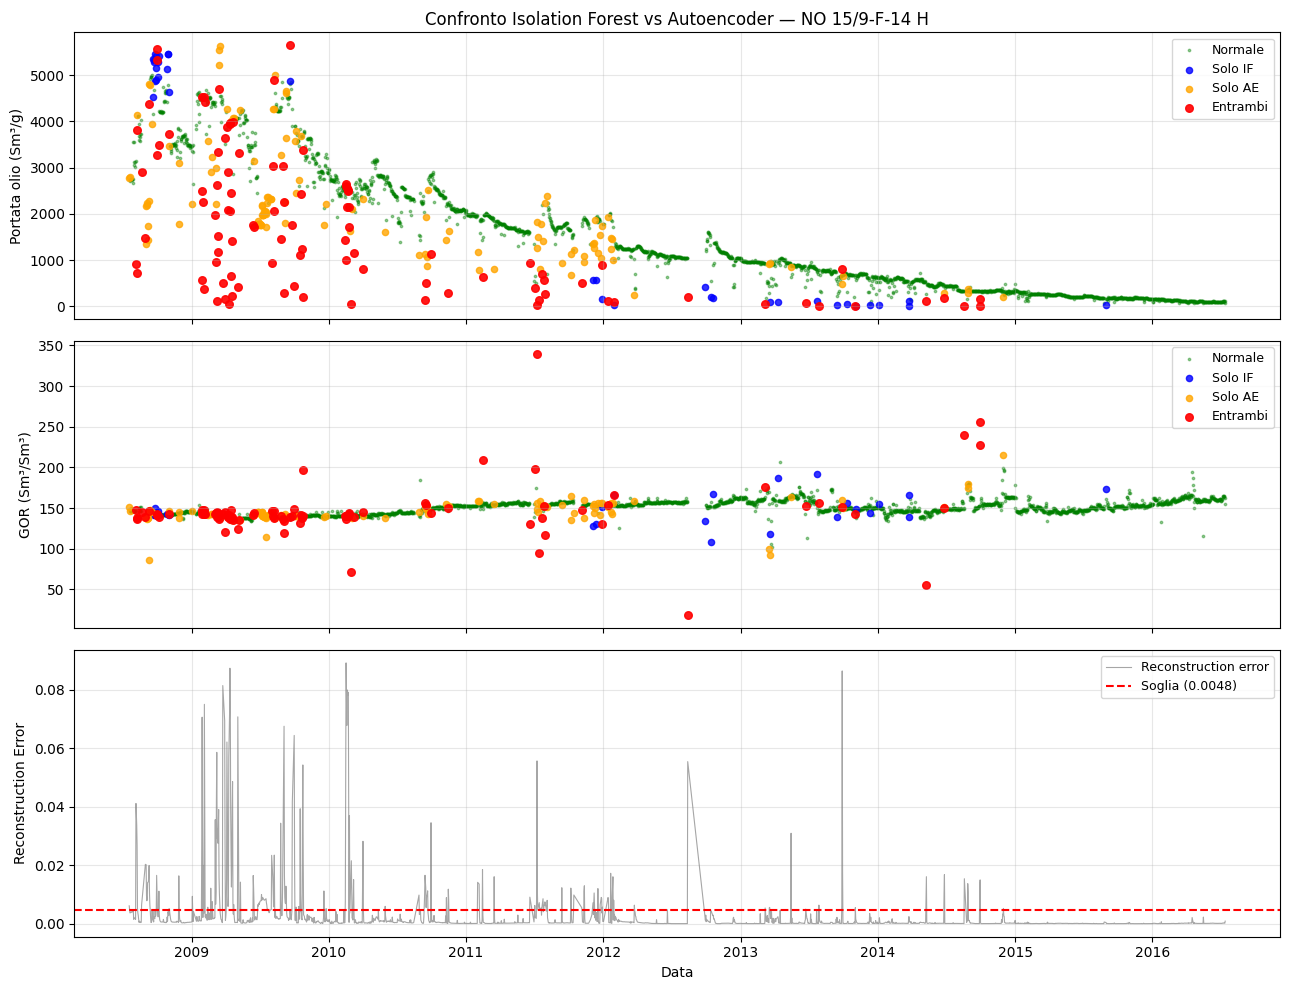

In [8]:
# ── VISUALIZZAZIONE CONFRONTO IF vs AUTOENCODER ───────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Categorie di anomalie
solo_if  = (df_ad['ANOMALY_IF'] == -1) & (df_ad['ANOMALY_AE'] ==  1)
solo_ae  = (df_ad['ANOMALY_IF'] ==  1) & (df_ad['ANOMALY_AE'] == -1)
entrambi = (df_ad['ANOMALY_IF'] == -1) & (df_ad['ANOMALY_AE'] == -1)
normali  = (df_ad['ANOMALY_IF'] ==  1) & (df_ad['ANOMALY_AE'] ==  1)

# ── Grafico 1: Produzione olio ──
axes[0].scatter(df_ad[normali]['DATEPRD'],  df_ad[normali]['BORE_OIL_VOL'],
                color='green',  s=3, alpha=0.4, label='Normale')
axes[0].scatter(df_ad[solo_if]['DATEPRD'],  df_ad[solo_if]['BORE_OIL_VOL'],
                color='blue',   s=20, alpha=0.8, label='Solo IF')
axes[0].scatter(df_ad[solo_ae]['DATEPRD'],  df_ad[solo_ae]['BORE_OIL_VOL'],
                color='orange', s=20, alpha=0.8, label='Solo AE')
axes[0].scatter(df_ad[entrambi]['DATEPRD'], df_ad[entrambi]['BORE_OIL_VOL'],
                color='red',    s=30, alpha=0.9, label='Entrambi')
axes[0].set_ylabel('Portata olio (Sm³/g)')
axes[0].set_title(f'Confronto Isolation Forest vs Autoencoder — {pozzo}')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Grafico 2: GOR ──
axes[1].scatter(df_ad[normali]['DATEPRD'],  df_ad[normali]['GOR'],
                color='green',  s=3, alpha=0.4, label='Normale')
axes[1].scatter(df_ad[solo_if]['DATEPRD'],  df_ad[solo_if]['GOR'],
                color='blue',   s=20, alpha=0.8, label='Solo IF')
axes[1].scatter(df_ad[solo_ae]['DATEPRD'],  df_ad[solo_ae]['GOR'],
                color='orange', s=20, alpha=0.8, label='Solo AE')
axes[1].scatter(df_ad[entrambi]['DATEPRD'], df_ad[entrambi]['GOR'],
                color='red',    s=30, alpha=0.9, label='Entrambi')
axes[1].set_ylabel('GOR (Sm³/Sm³)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Grafico 3: Reconstruction error ──
axes[2].plot(df_ad['DATEPRD'], df_ad['RECON_ERROR'],
             color='gray', linewidth=0.8, alpha=0.7, label='Reconstruction error')
axes[2].axhline(soglia, color='red', linestyle='--', linewidth=1.5, label=f'Soglia ({soglia:.4f})')
axes[2].set_ylabel('Reconstruction Error')
axes[2].set_xlabel('Data')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ── TABELLA COMPARATIVA FINALE ────────────────────────────────────────────────

solo_if_n  = ((df_ad['ANOMALY_IF'] == -1) & (df_ad['ANOMALY_AE'] ==  1)).sum()
solo_ae_n  = ((df_ad['ANOMALY_IF'] ==  1) & (df_ad['ANOMALY_AE'] == -1)).sum()
entrambi_n = ((df_ad['ANOMALY_IF'] == -1) & (df_ad['ANOMALY_AE'] == -1)).sum()

print("══ CONFRONTO FINALE ANOMALY DETECTION ══\n")
print(f"{'Metrica':<35} {'Isolation Forest':>18} {'Autoencoder':>13}")
print("-" * 68)
print(f"{'Anomalie totali rilevate':<35} {'136':>18} {'230':>13}")
print(f"{'Percentuale sul dataset':<35} {'5.0%':>18} {'8.5%':>13}")
print(f"{'Anomalie esclusive':<35} {solo_if_n:>18} {solo_ae_n:>13}")
print(f"{'Anomalie confermate da entrambi':<35} {entrambi_n:>18} {entrambi_n:>13}")
print(f"{'Approccio':<35} {'Statistico':>18} {'Deep Learning':>13}")
print(f"{'Training richiesto':<35} {'No (unsupervised)':>18} {'Si (solo normali)':>13}")
print(f"\nRaccomandazione operativa:")
print(f"  Usare ENTRAMBI in ensemble: anomalie confermate da entrambi = alta priorita'")
print(f"  Anomalie da uno solo = media priorita', richiedono verifica manuale")

══ CONFRONTO FINALE ANOMALY DETECTION ══

Metrica                               Isolation Forest   Autoencoder
--------------------------------------------------------------------
Anomalie totali rilevate                           136           230
Percentuale sul dataset                           5.0%          8.5%
Anomalie esclusive                                  35           129
Anomalie confermate da entrambi                    101           101
Approccio                                   Statistico Deep Learning
Training richiesto                   No (unsupervised) Si (solo normali)

Raccomandazione operativa:
  Usare ENTRAMBI in ensemble: anomalie confermate da entrambi = alta priorita'
  Anomalie da uno solo = media priorita', richiedono verifica manuale
